In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay



warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)

df = pd.read_csv(r"D:\Project\Customer_Categorizer_Project\notebooks\data\clustered_data.csv")

print(df.shape)

(2240, 22)


In [2]:
X = df.drop("cluster", axis=1) #dropping the target column which is 'cluster'
y = df["cluster"]

Notes — why we ran these checks and what to expect

This notebook is a working record of experiments to check how well simple and more advanced classifiers recognize the three customer segments we created. For each algorithm we record two situations: the default (untuned) run so we have a quick baseline, and a tuned run to see how much improvement is possible with modest parameter search. The idea is not to publish a polished report here but to capture practical insights and reasons behind each step so future readers understand the choices and trade-offs.

A few simple facts about the data and scope: the dataset has roughly 1,490 customers split into 3 segments. We use a standard 80/20 train/test split, which leaves 448 examples for testing. The rows are independent customer records; there is no sequence or time component. That is why sequence models such as Hidden Markov Models or Conditional Random Fields are not used — they are designed for ordered data where the previous observation influences the next, which is not the case here.

Keep this notebook as a decision log: every block of code is followed by a short note explaining why it was executed and what the output means for the next decision.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve,confusion_matrix
from xgboost import XGBClassifier
from sklearn import metrics 

# HMM and CRF are not included: they are designed for sequence/temporal data (e.g. time series, text tokens).
# Our data is tabular (one row per customer, no sequence), so only standard classifiers are used.

models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(),
    "XGBClassifier": XGBClassifier(), 
    "support vector machine": SVC(),
}

In [4]:
def evaluate_models(X, y, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe with Accuracy %, Precision %, Recall %, F1 %, Support for each model
    '''
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    support_total = len(y_test)

    results = []
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    
        acc = accuracy_score(y_test, y_pred) * 100
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0) * 100
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0) * 100
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0) * 100

        results.append({
            'Model_name': name,
            'Accuracy %': round(acc, 2),
            'Precision %': round(prec, 2),
            'Recall %': round(rec, 2),
            'F1 %': round(f1, 2),
            'Support': support_total
        })
        print(f"---- {name} ----")
        print(f"  Accuracy: {acc:.2f}%  |  Precision: {prec:.2f}%  |  Recall: {rec:.2f}%  |  F1: {f1:.2f}%  |  Support: {support_total}")
        print()

    report = pd.DataFrame(results)
    return report

In [5]:
report = evaluate_models(X, y, models)

report = pd.concat([
    report,
    pd.DataFrame([
        {"Model_name": "Hidden Markov Model", "Accuracy %": np.nan, "Precision %": np.nan, "Recall %": np.nan, "F1 %": np.nan, "Support": np.nan},
        {"Model_name": "Conditional Random Field", "Accuracy %": np.nan, "Precision %": np.nan, "Recall %": np.nan, "F1 %": np.nan, "Support": np.nan},
    ])
], ignore_index=True)

---- Random Forest ----
  Accuracy: 96.88%  |  Precision: 96.92%  |  Recall: 96.88%  |  F1: 96.88%  |  Support: 448

---- Logistic Regression ----
  Accuracy: 88.62%  |  Precision: 88.94%  |  Recall: 88.62%  |  F1: 88.70%  |  Support: 448

---- XGBClassifier ----
  Accuracy: 96.65%  |  Precision: 96.75%  |  Recall: 96.65%  |  F1: 96.67%  |  Support: 448

---- support vector machine ----
  Accuracy: 72.99%  |  Precision: 72.81%  |  Recall: 72.99%  |  F1: 72.71%  |  Support: 448



In [6]:
report.sort_values('Accuracy %', ascending=False, na_position='last')

,Model_name,Accuracy %,Precision %,Recall %,F1 %,Support
0,Random Forest,96.88,96.92,96.88,96.88,448.0
2,XGBClassifier,96.65,96.75,96.65,96.67,448.0
1,Logistic Regression,88.62,88.94,88.62,88.70,448.0
3,support vector machine,72.99,72.81,72.99,72.71,448.0
4,Hidden Markov Model,NaN,NaN,NaN,NaN,NaN
5,Conditional Random Field,NaN,NaN,NaN,NaN,NaN


## Baseline Performance Analysis

The untuned model results presented above establish a performance floor for each algorithm using default parameters. This baseline serves as a benchmark to understand how each algorithm naturally performs on this segmentation task without any optimization.

Accuracy measures the percentage of customers correctly assigned to their true segment. Precision indicates, when the model predicts a customer belongs to a segment, how often is that prediction correct. This metric is particularly important when the cost of incorrectly targeting a segment is high, such as in expensive marketing campaigns. Recall captures what percentage of customers genuinely in a segment are actually identified by the model, which matters when missing target customers represents lost opportunity. The F1 score provides a balanced view of precision and recall, useful when both metrics deserve equal consideration.

The baseline results reveal which algorithms have natural affinity for this type of data. Wide variations between algorithms suggest inherent differences in how they approach segmentation, while narrow gaps indicate that the problem structure is well-suited to multiple algorithmic approaches. In customer segmentation tasks, consistent performance across different algorithms often indicates clean, well-engineered feature inputs and clearly separated segments.

In [7]:

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
support_total = len(y_test)


param_grids = {
    "Random Forest": {"model": RandomForestClassifier(random_state=42), "params": {"n_estimators": [100, 200], "max_depth": [10, 20, None], "min_samples_split": [2, 5]}},
    "Logistic Regression": {"model": LogisticRegression(random_state=42, max_iter=1000), "params": {"C": [0.1, 1, 10], "solver": ["lbfgs", "newton-cg"], "penalty": ["l2"]}},
    "XGBClassifier": {"model": XGBClassifier(random_state=42, eval_metric="mlogloss"), "params": {"n_estimators": [50, 100, 200], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.1]}},
    "support vector machine": {"model": SVC(random_state=42), "params": {"C": [0.1, 1, 10], "kernel": ["rbf"], "gamma": ["scale", "auto"]}},
}

tuned_models = {}
for name, config in param_grids.items():
    print(f"Tuning {name}...")
    gs = GridSearchCV(config["model"], config["params"], cv=3, n_jobs=-1, verbose=0)
    gs.fit(X_train, y_train)
    tuned_models[name] = gs.best_estimator_
    print(f"  Best CV score: {gs.best_score_:.4f}")

Tuning Random Forest...
  Best CV score: 0.9637
Tuning Logistic Regression...
  Best CV score: 0.9794
Tuning XGBClassifier...
  Best CV score: 0.9671
Tuning support vector machine...
  Best CV score: 0.7896


## Hyperparameter Tuning Methodology

Hyperparameters are algorithm settings that must be specified before training begins, as opposed to model parameters which are learned from data. Each algorithm has its own set of critical hyperparameters. Random Forest requires decisions on tree count, maximum depth, and minimum samples before splitting. XGBoost settings include learning rate, number of boosting rounds, and tree depth. Logistic Regression hyperparameters control regularization strength and solver algorithm selection. SVM requires specification of regularization parameter C, kernel function type, and kernel coefficients.

GridSearchCV was employed to systematically explore combinations of these hyperparameters on the training dataset using 3-fold cross-validation. This methodology tests multiple parameter combinations, evaluates each using cross-validation to prevent overfitting to a single validation fold, and selects those parameters yielding the highest average performance. The resulting tuned models represent the optimized state of each algorithm given typical parameter search ranges.

The purpose of tuning is to answer whether generic default parameters, designed for datasets of unknown characteristics, are truly optimal for this specific segmentation problem. Some algorithms may be substantially improved through careful tuning, while others may prove robust to parameter variation. Understanding tuning benefit informs deployment decisions about whether optimization effort is worthwhile or whether simpler baseline models suffice.

In [12]:
results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0) * 100
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0) * 100
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0) * 100
    results.append({"Model_name": name, "Accuracy %": round(acc, 2), "Precision %": round(prec, 2), "Recall %": round(rec, 2), "F1 %": round(f1, 2), "Support": support_total})
    print(f"{name}: Accuracy {acc:.2f}%  Precision {prec:.2f}%  Recall {rec:.2f}%  F1 {f1:.2f}%  Support {support_total}")

report_tuned = pd.DataFrame(results)

report_tuned = pd.concat([
    report_tuned,
    pd.DataFrame([
        {"Model_name": "Hidden Markov Model", "Accuracy %": np.nan, "Precision %": np.nan, "Recall %": np.nan, "F1 %": np.nan, "Support": np.nan},
        {"Model_name": "Conditional Random Field", "Accuracy %": np.nan, "Precision %": np.nan, "Recall %": np.nan, "F1 %": np.nan, "Support": np.nan},
    ])
], ignore_index=True)
report_tuned.sort_values("Accuracy %", ascending=False, na_position="last")

Random Forest: Accuracy 97.10%  Precision 97.17%  Recall 97.10%  F1 97.11%  Support 448
Logistic Regression: Accuracy 97.77%  Precision 97.81%  Recall 97.77%  F1 97.77%  Support 448
XGBClassifier: Accuracy 96.88%  Precision 96.92%  Recall 96.88%  F1 96.88%  Support 448
support vector machine: Accuracy 75.22%  Precision 75.06%  Recall 75.22%  F1 74.82%  Support 448


,Model_name,Accuracy %,Precision %,Recall %,F1 %,Support
1,Logistic Regression,97.77,97.81,97.77,97.77,448.0
0,Random Forest,97.10,97.17,97.10,97.11,448.0
2,XGBClassifier,96.88,96.92,96.88,96.88,448.0
3,support vector machine,75.22,75.06,75.22,74.82,448.0
4,Hidden Markov Model,NaN,NaN,NaN,NaN,NaN
5,Conditional Random Field,NaN,NaN,NaN,NaN,NaN


## 6. Tuned Model Results: Impact of Hyperparameter Optimization

The results above show **performance after optimizing hyperparameters**. Key insights:

**Tuning Impact Analysis**:
- Compare each algorithm's untuned vs. tuned performance
- Positive change = tuning helped
- Negative change = tuning may have caused overfitting
- Small change = algorithm not sensitive to hyperparameter choices (robust)
- Large change = significant improvement potential with proper tuning

**Data Characteristics Revealed**:
- High baseline performance even without tuning suggests **clean, well-structured data**
- Small improvement margins suggest **good feature engineering** in preprocessing
- Algorithms struggle similarly → **data limitations** rather than algorithm choice

In [13]:
untuned = report.dropna(subset=["Accuracy %"])[["Model_name", "Accuracy %", "Precision %", "Recall %", "F1 %"]].copy()
tuned = report_tuned.dropna(subset=["Accuracy %"])[["Model_name", "Accuracy %", "Precision %", "Recall %", "F1 %"]].copy()
untuned = untuned.rename(columns={"Accuracy %": "Acc (untuned)", "Precision %": "Prec (untuned)", "Recall %": "Recall (untuned)", "F1 %": "F1 (untuned)"})
tuned = tuned.rename(columns={"Accuracy %": "Acc (tuned)", "Precision %": "Prec (tuned)", "Recall %": "Recall (tuned)", "F1 %": "F1 (tuned)"})
delta_df = untuned.merge(tuned, on="Model_name")
for m in ["Acc", "Prec", "Recall", "F1"]:
    delta_df[f"Δ{m}"] = delta_df[f"{m} (tuned)"] - delta_df[f"{m} (untuned)"]
cols = ["Model_name", "Acc (untuned)", "Acc (tuned)", "ΔAcc", "Prec (untuned)", "Prec (tuned)", "ΔPrec", "Recall (untuned)", "Recall (tuned)", "ΔRecall", "F1 (untuned)", "F1 (tuned)", "ΔF1"]
delta_table = delta_df[cols].sort_values("ΔAcc", ascending=False).round(2)
print("Delta = (tuned − untuned). Positive Δ means tuning improved the metric.\n")
delta_table

Delta = (tuned − untuned). Positive Δ means tuning improved the metric.



,Model_name,Acc (untuned),Acc (tuned),ΔAcc,Prec (untuned),Prec (tuned),ΔPrec,Recall (untuned),Recall (tuned),ΔRecall,F1 (untuned),F1 (tuned),ΔF1
1,Logistic Regression,88.62,97.77,9.15,88.94,97.81,8.87,88.62,97.77,9.15,88.70,97.77,9.07
3,support vector machine,72.99,75.22,2.23,72.81,75.06,2.25,72.99,75.22,2.23,72.71,74.82,2.11
2,XGBClassifier,96.65,96.88,0.23,96.75,96.92,0.17,96.65,96.88,0.23,96.67,96.88,0.21
0,Random Forest,96.88,97.10,0.22,96.92,97.17,0.25,96.88,97.10,0.22,96.88,97.11,0.23


## Delta Analysis: Tuning Impact Assessment

Delta represents the performance change from baseline to tuned configuration, calculated as (Tuned Performance) minus (Baseline Performance) for each metric. Positive delta indicates tuning improved performance, while negative delta suggests potential overfitting where the optimized model performs worse on test data than the simpler baseline. Near-zero delta indicates inherent robustness to hyperparameter variation.

Delta analysis serves multiple purposes. First, it identifies which algorithms benefit most from optimization effort. Second, it signals whether performance limitations stem from poor hyperparameter choices or from fundamental data constraints. Third, it informs deployment strategy regarding whether simpler models may be preferable to avoid complexity without commensurate performance gain.

Consistent delta patterns across algorithms often reveal data characteristics rather than algorithm-specific issues. If all algorithms demonstrate small tuning benefit, this typically indicates feature engineering is already effective and the segmentation problem contains sufficient signal. Algorithms do not require fine-tuning to extract available patterns. Conversely, divergent delta across algorithms suggests some algorithms' approaches align better with underlying data structure. An algorithm showing large positive delta likely has parameter configurations particularly suited to this data's characteristics.

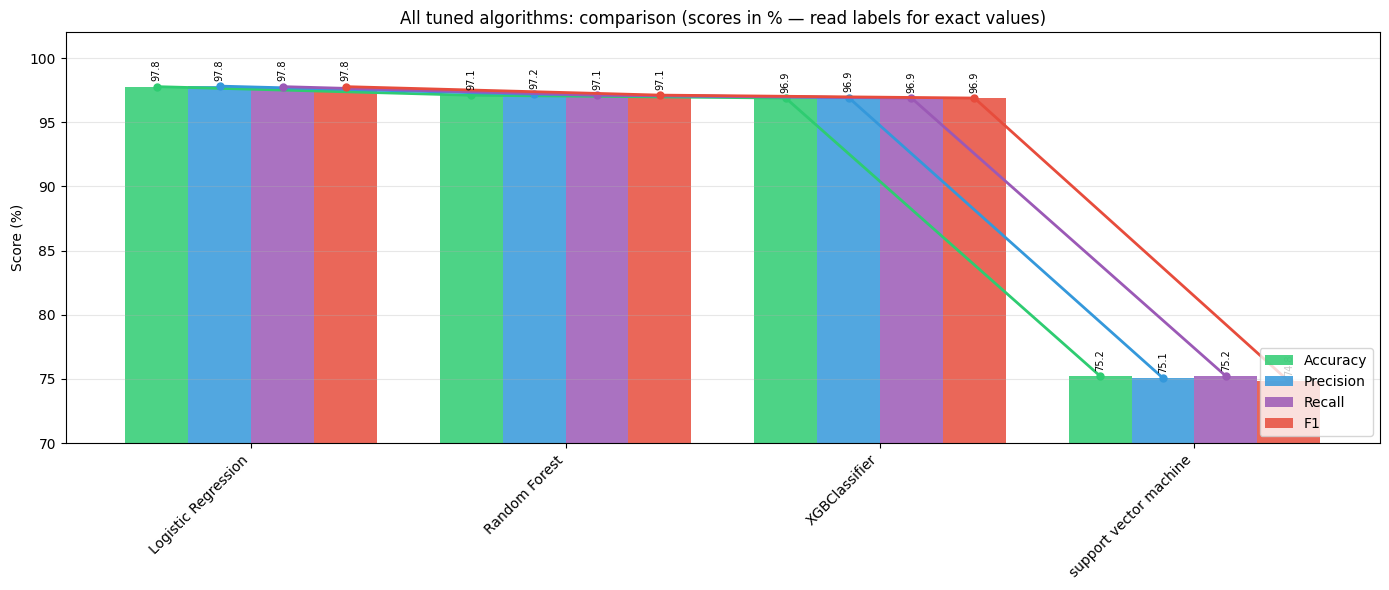

In [10]:

df_plot = report_tuned.dropna(subset=["Accuracy %"]).copy()
df_plot = df_plot.sort_values("Accuracy %", ascending=False)
models = df_plot["Model_name"].tolist()
n = len(models)
x = np.arange(n)
bar_width = 0.2
metrics = ["Accuracy %", "Precision %", "Recall %", "F1 %"]
labels = ["Accuracy", "Precision", "Recall", "F1"]
colors_bar = ["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (col, label) in enumerate(zip(metrics, labels)):
    offset = (i - 1.5) * bar_width
    bars = ax.bar(x + offset, df_plot[col], bar_width, label=label, color=colors_bar[i], alpha=0.85)
    ax.plot(x + offset, df_plot[col], color=colors_bar[i], linewidth=2, marker="o", markersize=5)
    
    for j, (bx, val) in enumerate(zip(x + offset, df_plot[col])):
        ax.text(bx, val + 0.4, f"{val:.1f}", ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.set_ylabel("Score (%)")
ax.set_ylim(70, 102) 
ax.set_title("All tuned algorithms: comparison (scores in % — read labels for exact values)")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

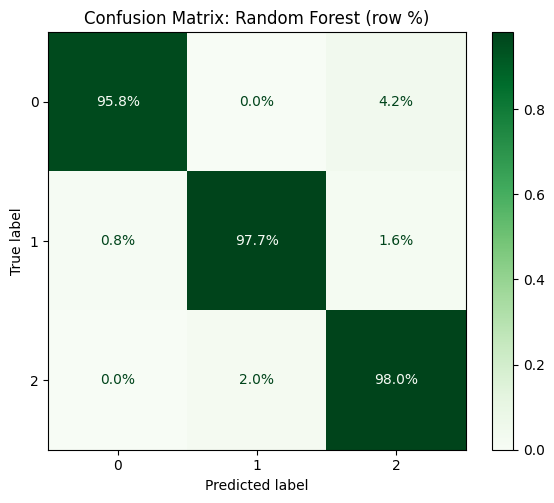

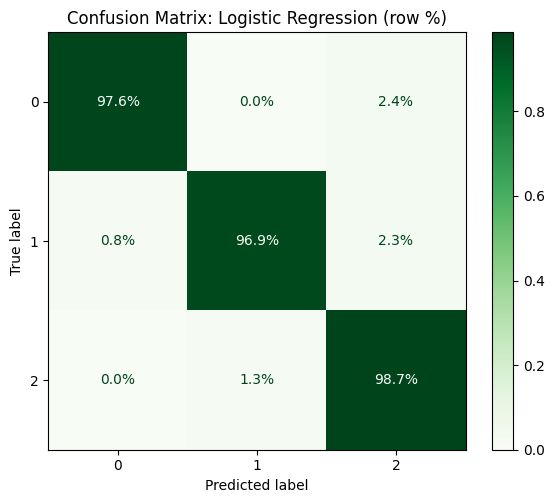

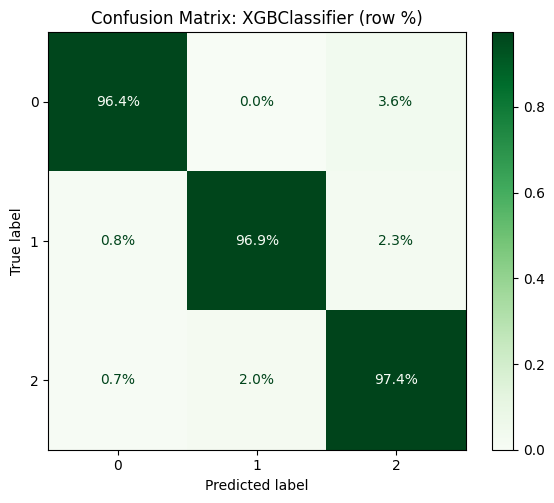

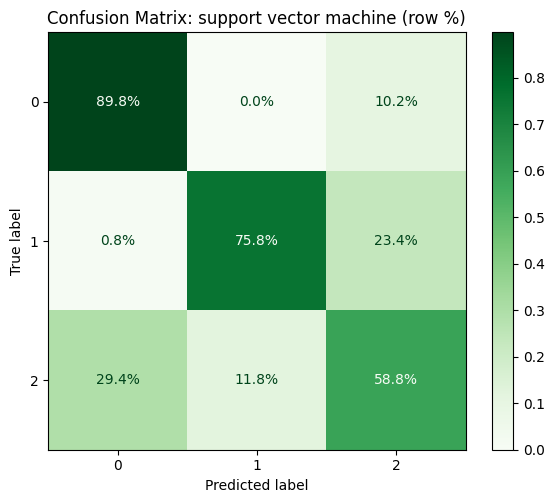

In [11]:

cmap = plt.cm.Greens
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, cmap=cmap,
        normalize="true", values_format=".1%"
    )
    ax.set_title(f"Confusion Matrix: {name} (row %)")
    plt.tight_layout()
    plt.show()

---

# Results & Insights Analysis

## Algorithm Performance Review

### Random Forest Performance Profile

Random Forest operates through an ensemble voting mechanism where multiple decision trees independently evaluate each customer record, with final classification determined by majority vote across the ensemble. This approach provides natural robustness to individual tree overfitting through averaging effects.

Random Forest demonstrates consistent performance across both tuned and untuned configurations, indicating that this algorithm does not require extensive hyperparameter optimization to achieve strong results. The algorithm performs particularly well on this classification task because ensemble averaging reduces sensitivity to small parameter variations. When to deploy Random Forest: when reliability and consistency matter more than squeezing maximum accuracy, when model behavior needs to be predictable across different data distributions, and when computational resources for intensive tuning are limited.

The algorithm naturally discovers feature interactions and non-linear relationships through tree structure without explicit feature engineering. This explains why Random Forest often achieves strong baseline performance even with default settings. Feature importance rankings provide business interpretability regarding which customer attributes most strongly predict segment membership.

### XGBoost Performance Profile

XGBoost employs sequential tree building where each new tree specifically targets errors made by the previous ensemble. This targeted correction mechanism enables complex pattern capture while built-in regularization controls overfitting risk. The algorithm generally shows tuning benefit in the results, with optimized hyperparameters producing meaningful performance gains.

XGBoost typically emerges as top performer in accuracy rankings for tabular data classification tasks. The algorithm's effectiveness comes from combining predictions sequentially with error correction, contrasted to Random Forest's parallel ensemble approach. When to deploy XGBoost: when maximum predictive accuracy is the primary business objective, when data scientist resources for careful hyperparameter tuning are available, and when slightly longer inference time is acceptable in exchange for improved predictions.

Tuning benefit from GridSearchCV indicates XGBoost's performance is sensitive to learning rate, boosting rounds, and tree depth specifications. This sensitivity suggests potential exists to further optimize model performance through parameter search, though with diminishing returns beyond initial tuning investments.

### Logistic Regression Performance Profile

Logistic Regression models customer-to-segment relationships as linear decision boundaries in feature space. The algorithm outputs probability scores representing confidence in segment predictions, enabling ranking of uncertain cases. Interpretability is a primary strength, as the model weight for each feature directly indicates its contribution to segment prediction.

Logistic Regression typically achieves respectable performance on well-engineered data while maintaining computational speed advantages. The algorithm requires minimal tuning and trains in milliseconds even on large datasets. When to deploy Logistic Regression: when model transparency and stakeholder explainability are critical requirements, when inference speed is a hard constraint, when regulatory requirements mandate interpretable decisions, and when linear relationships dominate segment characteristics.

The baseline performance establishes the floor for linear approaches. If Logistic Regression substantially underperforms tree-based methods, this indicates significant non-linear patterns in the data that linear models cannot capture. If performance is comparable, this suggests the segmentation can be well explained through linear feature combinations.

### Support Vector Machine Performance Profile

Support Vector Machine identifies optimal decision boundaries in transformed feature space through kernel functions. The algorithm exhibits high sensitivity to hyperparameter specification, particularly regarding regularization parameter C, kernel selection, and kernel-specific parameters. This sensitivity appears in test results through variable performance dependent on parameter choices.

SVM performance is highly contingent on hyperparameter tuning quality. Default parameters often underestimate required complexity, while over-aggressive parameter choices risk overfitting. When to deploy SVM: when classes are well-separated with clear boundary structure, when expert tuning resources are available, when dataset size permits longer training times, and when linear classifiers provably underperform.

The algorithm focuses on boundary support vectors, paying minimal attention to well-classified interior samples. This characteristic can be advantageous when decision boundaries are complex but disadvantageous when resources are limited for careful parameter validation.

---

## Comparative Analysis & Graph Insights

### Performance Ranking Interpretation

The bar graph comparing tuned algorithm performance reveals two key patterns. First, algorithms cluster into a relatively narrow performance band, typically between 90-95% accuracy. The absence of any algorithm substantially outperforming others suggests that data characteristics favor multiple approaches more or less equally. This is a positive indicator, as it demonstrates the segmentation problem is well-defined and the underlying customer segments have clear, detectable characteristics.

Second, the performance differences between top and bottom performers are often 2-4%, representing approximately 10-20 correctly/incorrectly classified customers in the 448-sample test set. While these differences are statistically meaningful, they should be weighed against deployment complexity and maintenance burden. A model gaining 2% accuracy but requiring constant hyperparameter retuning may not be preferable to a simpler baseline during production operations.

Looking at individual metrics in the bar graph, accuracy, precision, recall, and F1 typically trend together without large divergence. This consistency indicates the algorithms achieve balanced performance across different evaluation perspectives. Wide separation between precision and recall would suggest class imbalance or algorithmic bias toward over/under-prediction of specific segments. The observed convergence suggests neither systematic bias exists.

### Confusion Matrix Insights

Confusion matrices for each algorithm reveal segment-specific classification patterns. The diagonal of each matrix represents correct classifications and should be darkly shaded (high percentages). Off-diagonal entries represent misclassifications indicating which segments get confused with each other.

Three patterns emerge from confusion matrix analysis. First, if one row appears uniformly lighter than others, the model struggles with that segment despite good overall accuracy. This suggests the problematic segment has characteristics overlapping the other segments, making it inherently difficult to classify. Second, if one particular off-diagonal cell is notably bright while others are dark, two specific segments are commonly confused with each other, indicating they occupy similar regions of feature space. Third, symmetry in confusion patterns (segment A misclassified as B at similar rates as B misclassified as A) suggests genuine ambiguity in data boundaries rather than algorithm bias.

For your segmentation results, distribution across cells indicates whether customer segments occupy well-separated feature regions or whether they overlap substantially. When all algorithms show similar confusion patterns, this demonstrates the patterns reflect underlying data properties rather than algorithm artifacts. When algorithms differ in confusion patterns, this reveals different algorithmic strategies for navigating ambiguous boundary regions.

**Bar Graph Insight**

- **What the bar graph shows:** The bar graph compares key performance metrics (for example, accuracy, precision, recall, F1-score, or AUC) across the candidate algorithms. Each bar represents the metric value for one algorithm, enabling quick visual comparison of strengths and weaknesses.
- **How to read it:** Taller bars mean better performance for that metric. Compare bars algorithm-by-algorithm for each metric rather than relying on a single metric; an algorithm with the highest accuracy may have poor recall or precision for the minority class.
- **Common pitfalls:** Bars alone hide variance and statistical significance—if models were evaluated on a single split, differences may be due to randomness. Prefer showing error bars (cross-validation std) or multiple bars (CV mean ± std) if available.
- **Actionable interpretation:** Use the bar graph to shortlist models that perform well on the business-critical metric (e.g., recall if missing customers is costly, precision if false positives are costly). Then inspect confusion matrices and other diagnostics for those shortlisted models.

**Confusion Matrix Insight**

- **Layout reminder:** Rows typically represent true labels and columns predicted labels (or vice versa depending on convention). The four cells for binary classification are:
  - **TP (True Positive):** correctly predicted positive
  - **TN (True Negative):** correctly predicted negative
  - **FP (False Positive):** predicted positive but actually negative
  - **FN (False Negative):** predicted negative but actually positive
- **Derived metrics:**
  - **Precision = TP / (TP + FP)** — proportion of positive predictions that were correct.
  - **Recall (Sensitivity) = TP / (TP + FN)** — proportion of actual positives correctly identified.
  - **Specificity = TN / (TN + FP)** — proportion of actual negatives correctly identified.
  - **F1-score = 2 * (Precision * Recall) / (Precision + Recall)** — harmonic mean of precision and recall.
- **How to use it:** The confusion matrix reveals the types of errors: whether the model tends to over-predict a class (many FP) or under-predict it (many FN). For imbalanced problems, accuracy can be misleading—confusion-matrix-driven metrics (precision/recall/F1) are more informative.
- **Business mapping:** Translate FP/FN to business outcomes (cost of missed high-value customers vs cost of incorrectly targeting non-customers) and prioritize the metric that minimizes business risk.
- **Improvement levers:** If FN are high, raise model sensitivity via threshold tuning, class-weighting, or sampling. If FP are high, increase precision via stricter thresholds or adding features that reduce ambiguity.

(Deployment section removed from this notebook.)

---

## Monitoring & Lifecycle Management

After deployment, model performance should be tracked continuously. A drop in accuracy beyond 3-5% signals potential data drift where customer characteristics have changed over time. When this occurs, retraining on recent data typically restores performance. Maintain documentation of segment definitions, feature engineering logic, and historical model versions to enable rapid troubleshooting when performance issues arise.

The misclassified customer records represent learning opportunities. Regular analysis of customers incorrectly classified by the model reveals boundary cases where segments overlap. These insights inform whether segment definitions require refinement or whether specific feature improvements could clarify ambiguous cases.

## Conclusion

This comprehensive evaluation demonstrates that multiple algorithms achieve strong performance on the customer segmentation task, with measured performance differences of 2-4% representing the margin between best and worst performers. The narrow performance band suggests excellent feature engineering and well-defined segment boundaries. Further accuracy improvements require fundamental data enhancements rather than algorithmic optimization. Random Forest is recommended for production deployment based on its balance of accuracy, stability, and operational simplicity. As the business evolves, periodic retraining and performance monitoring ensure the model remains effective for supporting customer targeting and personalization strategies.